In [1]:
while True:
    op=int(input("Choose operation:\n1.Add\n2.Subtract\n3.Multiply\n4.Divide\n5.Exit\n"))
    if op==1:
        a,b=map(int,input("Enter two numbers:").split())
        result=a+b
        print(f"{a}+{b}={result}")
    elif op==2:
        a,b=map(int,input("Enter two numbers:").split())
        result=a-b
        print(f"{a}-{b}={result}")
    elif op==3:
        a,b=map(int,input("Enter two numbers:").split())
        result=a*b
        print(f"{a}*{b}={result}")
    elif op==4:
        a,b=map(float,input("Enter two numbers:").split())
        if b==0:
            print("Division by zero not possible.\n")
        else:
            result=a/b
            print(f"{a}/{b}={result}")
    elif op==5:
        print("Exiting...\n")
        break
    else:
        print("Invalid choice\n")

3+5=8
10-5=5
4*8=32
89.0/19.0=4.684210526315789
Division by zero not possible.

Exiting...



In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

file_path="/Users/aysha/Desktop/AI Internship/titanic (1).csv"

df=pd.read_csv(file_path)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [14]:
df.shape

(891, 12)

In [15]:
df.info

<bound method DataFrame.info of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                   

In [16]:
df.duplicated().value_counts()

False    891
Name: count, dtype: int64

In [17]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


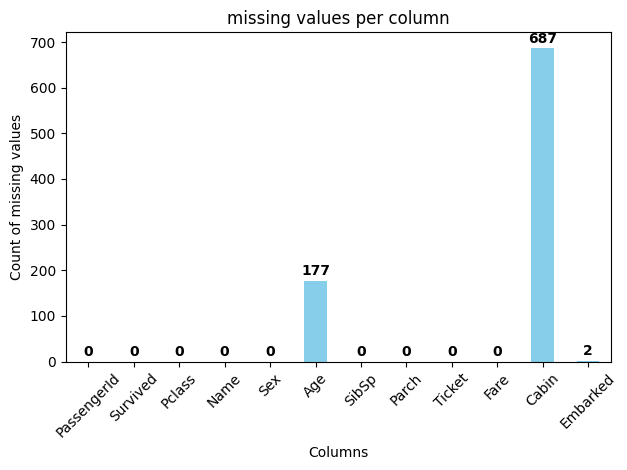

In [21]:
missing=df.isnull().sum()
ax=missing.plot(kind="bar",color="skyblue")
plt.title("missing values per column")
plt.xlabel("Columns")
plt.ylabel("Count of missing values")
plt.xticks(rotation=45)

for index,value in enumerate(missing):
    plt.text(index,value+5,str(value),ha='center',va='bottom',fontsize=10,fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
df=df.drop(columns=['Cabin'])
df['Age']=df['Age'].fillna(df['Age'].median())
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

In [26]:
survival_counts=df['Survived'].value_counts()
print("Survival counts=",survival_counts)

Survival counts= Survived
0    549
1    342
Name: count, dtype: int64


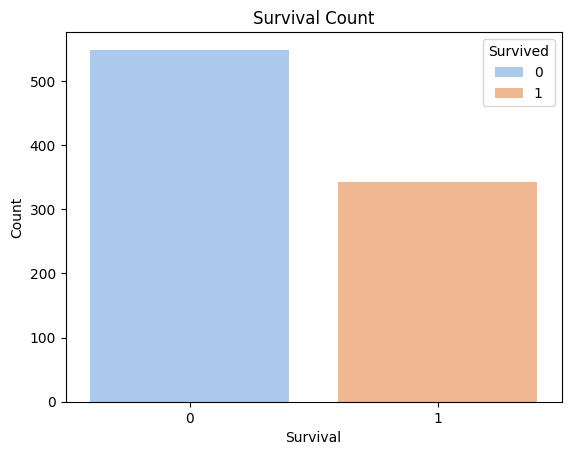

In [30]:
sns.countplot(x='Survived',data=df,hue='Survived',palette='pastel')
plt.title("Survival Count")
plt.xlabel("Survival")
plt.ylabel("Count")
plt.show()

In [28]:
gender_counts=df['Sex'].value_counts()
print("Gender count=",gender_counts)

Gender count= Sex
male      577
female    314
Name: count, dtype: int64


In [29]:
survival_by_gender=df.groupby(['Sex','Survived']).size()
print("Survival by gender=",survival_by_gender)

Survival by gender= Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
dtype: int64


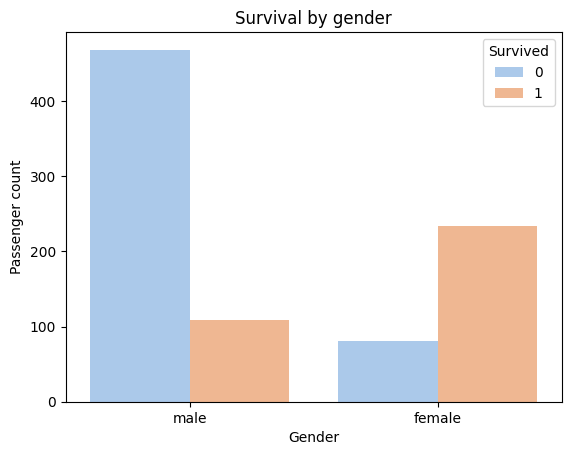

In [35]:
sns.countplot(x='Sex',hue='Survived',data=df,palette='pastel')
plt.title("Survival by gender")
plt.xlabel("Gender")
plt.ylabel("Passenger count")
plt.legend(title="Survived")
plt.show()

In [37]:
pclass_counts=df['Pclass'].value_counts()
print("Passenger class count=",pclass_counts)

Passenger class count= Pclass
3    491
1    216
2    184
Name: count, dtype: int64


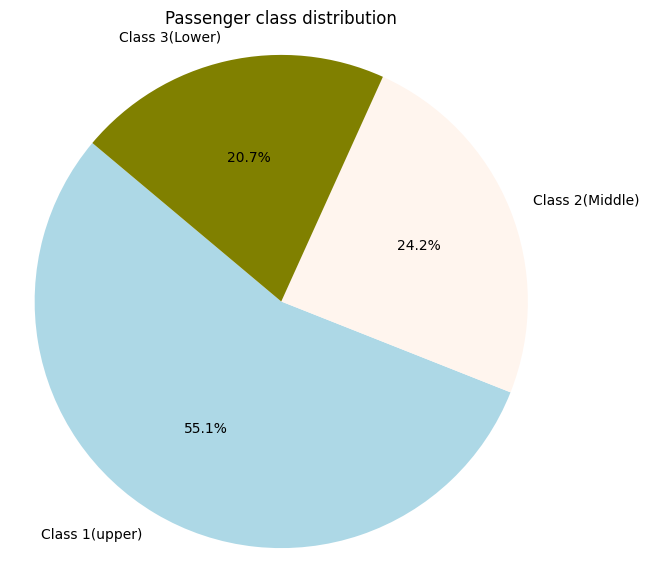

In [38]:
labels=["Class 1(upper)","Class 2(Middle)","Class 3(Lower)"]
plt.figure(figsize=(7,7))
plt.pie(pclass_counts,labels=labels,autopct="%1.1f%%",startangle=140,colors=['lightblue','seashell','olive'])
plt.title("Passenger class distribution")
plt.axis('equal')
plt.show()

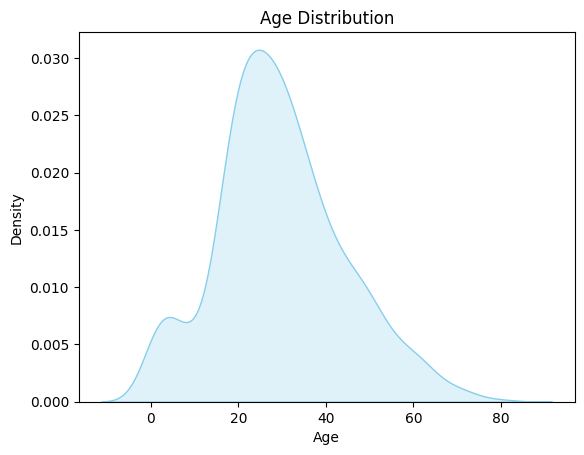

In [39]:
sns.kdeplot(df['Age'],fill=True,color='skyblue')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Density")
plt.show()

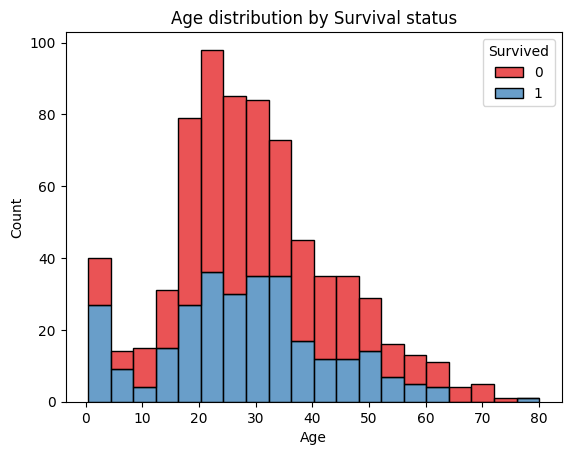

In [40]:
sns.histplot(x='Age',hue='Survived',data=df,multiple='stack',bins=20,palette='Set1')
plt.title("Age distribution by Survival status")
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

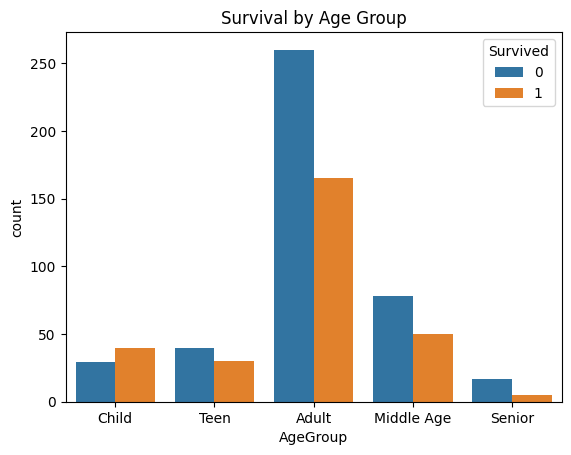

In [41]:
df['AgeGroup']=pd.cut(df['Age'],bins=[0,12,18,40,60,100],labels=['Child','Teen','Adult','Middle Age','Senior'])
sns.countplot(x='AgeGroup',hue='Survived',data=df)
plt.title("Survival by Age Group")
plt.show()